<a href="https://colab.research.google.com/github/dmdevinc/shearwaters-climate/blob/main/Shollenberger.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Shollenberger Project, 2026

How does surface water extent change seasonally in a wetland?

Tools:
- geemap: python package for google earth engine connection
- sentinel-2: satellite imagery

## Packages and Set Up

In [ ]:
# Install geemap
# info: https://pypi.org/project/geemap/
# pip install geemap

# Create a Google Earth Engine project and set up API
# info: https://colab.research.google.com/github/google/earthengine-community/blob/master/guides/linked/ee-api-colab-setup.ipynb#scrollTo=tRPULejJhBSl$0

In [ ]:
# Import
import ee # google earth engine
import geemap
import pandas as pd
import matplotlib.pyplot as plt # for graphs

ee.Authenticate()

# Initialize the google earth enginge library
ee.Initialize(project='shollenberger')

# Define Shollenberger coordinates
shollenberger_pt = ee.Geometry.Point([-122.598555, 38.224888]) # center point
# polgyon following walking path (points generated from Google Earth)
shollenberger_poly = ee.Geometry.Polygon([[
    [-122.5992786632553, 38.22787299030232],
    [-122.5995057705725, 38.22775678138207],
    [-122.5997720031113, 38.22778855180979],
    [-122.6007447555558, 38.22836596136636],
    [-122.6009384595212, 38.2284017086013],
    [-122.6011914505686, 38.22832943374195],
    [-122.6023200289863, 38.22729595894701],
    [-122.6033523372485, 38.22625763185358],
    [-122.6035407969382, 38.22602611353297],
    [-122.6037507225472, 38.22546372064151],
    [-122.6038939447859, 38.22497322173839],
    [-122.6041943829639, 38.22445645558448],
    [-122.6045497974704, 38.22412542340645],
    [-122.6051349534711, 38.22400798137608],
    [-122.6052809973936, 38.22389064782243],
    [-122.6051263447862, 38.22341572093131],
    [-122.6049534962698, 38.22299733108184],
    [-122.604705078659, 38.22262408638233],
    [-122.6034389928631, 38.22155762405112],
    [-122.6032220532315, 38.22145907648089],
    [-122.6027316330767, 38.22127285774164],
    [-122.6022224804258, 38.2212464607665],
    [-122.6018052846393, 38.22129731981555],
    [-122.6012044080092, 38.22142287769795],
    [-122.6006274690496, 38.2213722132961],
    [-122.5997868299647, 38.22113294199854],
    [-122.5991292065143, 38.22088512812334],
    [-122.5986956231249, 38.22087294298276],
    [-122.5970686967131, 38.22124335735403],
    [-122.5967591166156, 38.22147473749394],
    [-122.5963547978029, 38.22159013076342],
    [-122.5913845100954, 38.22704455629619],
    [-122.5914217050831, 38.22715776944863],
    [-122.5933484022996, 38.2279005887849],
    [-122.59350587967, 38.22790061423185],
    [-122.5937743661464, 38.22778519225154],
    [-122.5940382292535, 38.22777163795142],
    [-122.5957062383602, 38.22838683852322],
    [-122.5980032017346, 38.22906556223755],
    [-122.5982596565097, 38.22901986887084],
    [-122.5992786632553, 38.22787299030232]  # closes the polygon
]])

## Practice with Geemap

Pull information from Google Earth Enginge and create an basic interactive map.

In [ ]:
# Print ground surface height (elevation) of a given coordinate
dem = ee.Image('USGS/SRTMGL1_003') # NASA/USGS elevation dataset covering the entire Earth

xy = ee.Geometry.Point([-122.577829, 37.929088]) # Mt Tam coordinates
elev = dem.sample(xy, 30).first().get('elevation').getInfo() # at this coordinate, what's the elevation value in this image?
print('Mount Tamalpias elevation (m):', elev)

elev = dem.sample(shollenberger_pt, 30).first().get('elevation').getInfo()
print('Shollenberger elevation (m):', elev)

Mount Tamalpias elevation (m): 763
Shollenberger elevation (m): -2


In [ ]:
# Create a basic interactive map with elevations

# Set visualization parameters
vis_params = {
  'min': 0,
  'max': 4000,
  'palette': ['006633', 'E5FFCC', '662A00', 'D8D8D8', 'F5F5F5']}

# Create a map object
m = geemap.Map(center=[20, 0], zoom=3)

# Add the elevation model to the map object
m.add_ee_layer(dem.updateMask(dem.gt(0)), vis_params, 'DEM')

# Display the map
display(m)

Map(center=[20, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', trans…

## Normalized Difference Water Index (NDWI)

Water and land reflect light differently, where dry soil reflects visible green wavelengths (Green) and invisible near-infrared light (NIR) back relatively evenly, water absorbs almost all NIR. Normalized Difference Water Index (NDWI) is a remote sensing index that can be used to determine where NIR is low, effectively indicating where moisture exists.

  - Formula: (Green - NIR) / (Green + NIR)

In this project we will look at which pixels over Shollenberger have very low NIR, then count them. More low-NIR pixels = more water surface.

Sone downsides of this Index are that it is sensitive to built structures and can therefore over estimate water body size and cloud cover can add noise to the satellite imagery. There are no build structures within out study area however, and we will account for cloud cover below.

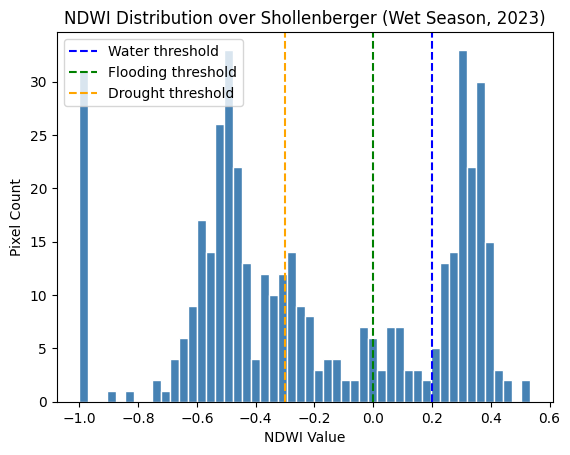

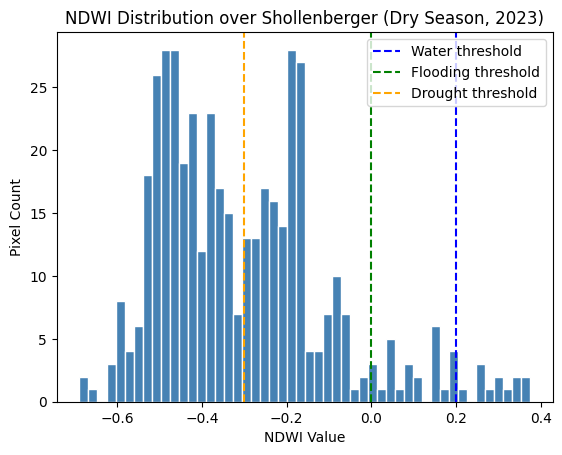

In [ ]:
# Explore NDWI of Shollenberger

# Load and Filter Sentinel 2 imagery
img = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')  # load collection
    .filterBounds(shollenberger_poly)  # filter by location
    .filterDate('2023-01-01', '2023-03-31') # select date range (random for practice)
    .sort('CLOUDY_PIXEL_PERCENTAGE')  # rank by cloud cover
    .first())  # grab least cloudy image

# Calculate NDWI
ndwi = img.normalizedDifference(['B3', 'B8']).rename('NDWI') # B3=Green, B8=NIR

# Sample 500 points
samp_fc = ndwi.sample(region=shollenberger_poly, scale=10, numPixels=500) # randomly sample 500 points at a 10 meter resolution
samp_dict = samp_fc.reduceColumns(ee.Reducer.toList(), ['NDWI']) # organize into a list
samp_data = ee.List(samp_dict.get('list')).getInfo() # pulls list from Google servers into Python

# Plot as histogram
import matplotlib.pyplot as plt
# makes 50 bins across the -1 to 1 range and counts how many pixels fall in each
plt.hist(samp_data, bins=50, color='steelblue', edgecolor='white')
plt.axvline(0.2, color='blue', linestyle='--', label='Water threshold')
plt.axvline(0.0, color='green', linestyle='--', label='Flooding threshold')
plt.axvline(-0.3, color='orange', linestyle='--', label='Drought threshold')
plt.xlabel('NDWI Value')
plt.ylabel('Pixel Count')
plt.title('NDWI Distribution over Shollenberger (Wet Season, 2023)')
plt.legend()
plt.show()

# Load and Filter Sentinel 2 imagery
img = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')  # load collection
    .filterBounds(shollenberger_poly)  # filter by location
    .filterDate('2023-07-01', '2023-09-30')  # select date range (random for practice)
    .sort('CLOUDY_PIXEL_PERCENTAGE')  # rank by cloud cover
    .first())  # grab least cloudy image

# Calculate NDWI
ndwi = img.normalizedDifference(['B3', 'B8']).rename('NDWI') # B3=Green, B8=NIR

# Sample 500 points
samp_fc = ndwi.sample(region=shollenberger_poly, scale=10, numPixels=500) # randomly sample 500 points at a 10 meter resolution
samp_dict = samp_fc.reduceColumns(ee.Reducer.toList(), ['NDWI']) # organize into a list
samp_data = ee.List(samp_dict.get('list')).getInfo() # pulls list from Google servers into Python

# Plot as histogram
import matplotlib.pyplot as plt
# makes 50 bins across the -1 to 1 range and counts how many pixels fall in each
plt.hist(samp_data, bins=50, color='steelblue', edgecolor='white')
plt.axvline(0.2, color='blue', linestyle='--', label='Water threshold')
plt.axvline(0.0, color='green', linestyle='--', label='Flooding threshold')
plt.axvline(-0.3, color='orange', linestyle='--', label='Drought threshold')
plt.xlabel('NDWI Value')
plt.ylabel('Pixel Count')
plt.title('NDWI Distribution over Shollenberger (Dry Season, 2023)')
plt.legend()
plt.show()

# The NDWI values correspond to the following ranges:
# 0,2 – 1 – Water surface, open water
# 0.0 – 0,2 – Flooding, humidity, saturated areas
# -0,3 – 0.0 – Moderate drought, non-aqueous surfaces,
# -1 – -0.3 – Drought, non-aqueous surfaces, walking trails

## Shollenberger Map

In [ ]:
# Generate map, centered on Shollenberger
Map = geemap.Map(center=[38.2249, -122.5986], zoom=16)

# Sentinel-2 image filtered to Shollenberger polygon
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(shollenberger_poly)
    .filterDate('2023-01-01', '2023-03-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .median())

# True color
vis_true = {'min': 0, 'max': 3000, 'bands': ['B4', 'B3', 'B2']}
Map.addLayer(s2, vis_true, 'True Color')

# NDWI
ndwi = s2.normalizedDifference(['B3', 'B8'])
vis_ndwi = {'min': -1, 'max': 1, 'palette': ['brown', 'white', 'blue']}
Map.addLayer(ndwi, vis_ndwi, 'NDWI')

# Add polygon boundary
empty = ee.Image().byte()
outline = empty.paint(
    featureCollection=ee.FeatureCollection([ee.Feature(shollenberger_poly)]),
    color=1,
    width=3  # border width in pixels
)
Map.addLayer(outline, {'palette': 'blue'}, 'Shollenberger')

Map

Map(center=[38.2249, -122.5986], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [ ]:
# Do the same thing for the dry season
Map = geemap.Map(center=[38.2249, -122.5986], zoom=16)

s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(shollenberger_poly)
    .filterDate('2023-07-01', '2023-09-30')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .median())

vis_true = {'min': 0, 'max': 3000, 'bands': ['B4', 'B3', 'B2']}
Map.addLayer(s2, vis_true, 'True Color')

ndwi = s2.normalizedDifference(['B3', 'B8'])
vis_ndwi = {'min': -1, 'max': 1, 'palette': ['brown', 'white', 'blue']}
Map.addLayer(ndwi, vis_ndwi, 'NDWI')

empty = ee.Image().byte()
outline = empty.paint(
    featureCollection=ee.FeatureCollection([ee.Feature(shollenberger_poly)]),
    color=1,
    width=3

Map.addLayer(outline, {'palette': 'red'}, 'Shollenberger')

Map

Map(center=[38.2249, -122.5986], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

## Monthly Seasonal Comparison

Compare NDWI monthly to identify when shifts occur in the hydrology.
- For each month of 2023, create a median composite and calculate NDWI
- Count pixels above 0.2 (open water threshold) inside the polygon
- Convert pixel count to hectares
- Plot month on x-axis, water area on y-axis

Month 1 done
Month 2 done
Month 3 done
Month 4 done
Month 5 done
Month 6 done
Month 7 done
Month 8 done
Month 9 done
Month 10 done
Month 11 done
Month 12 done


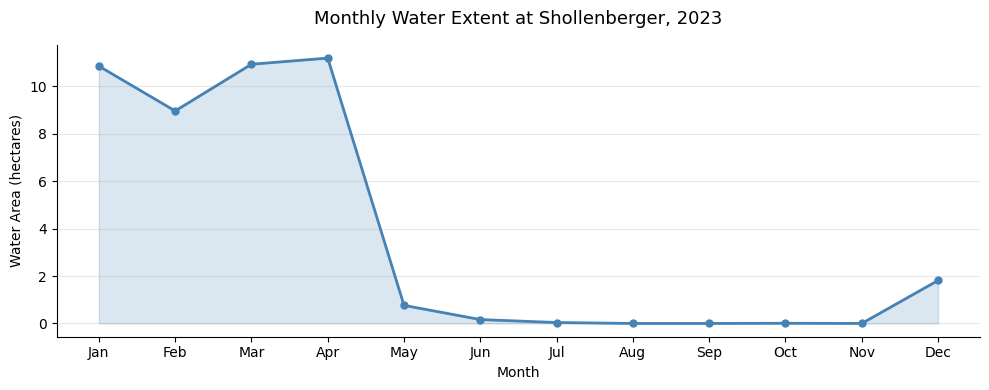

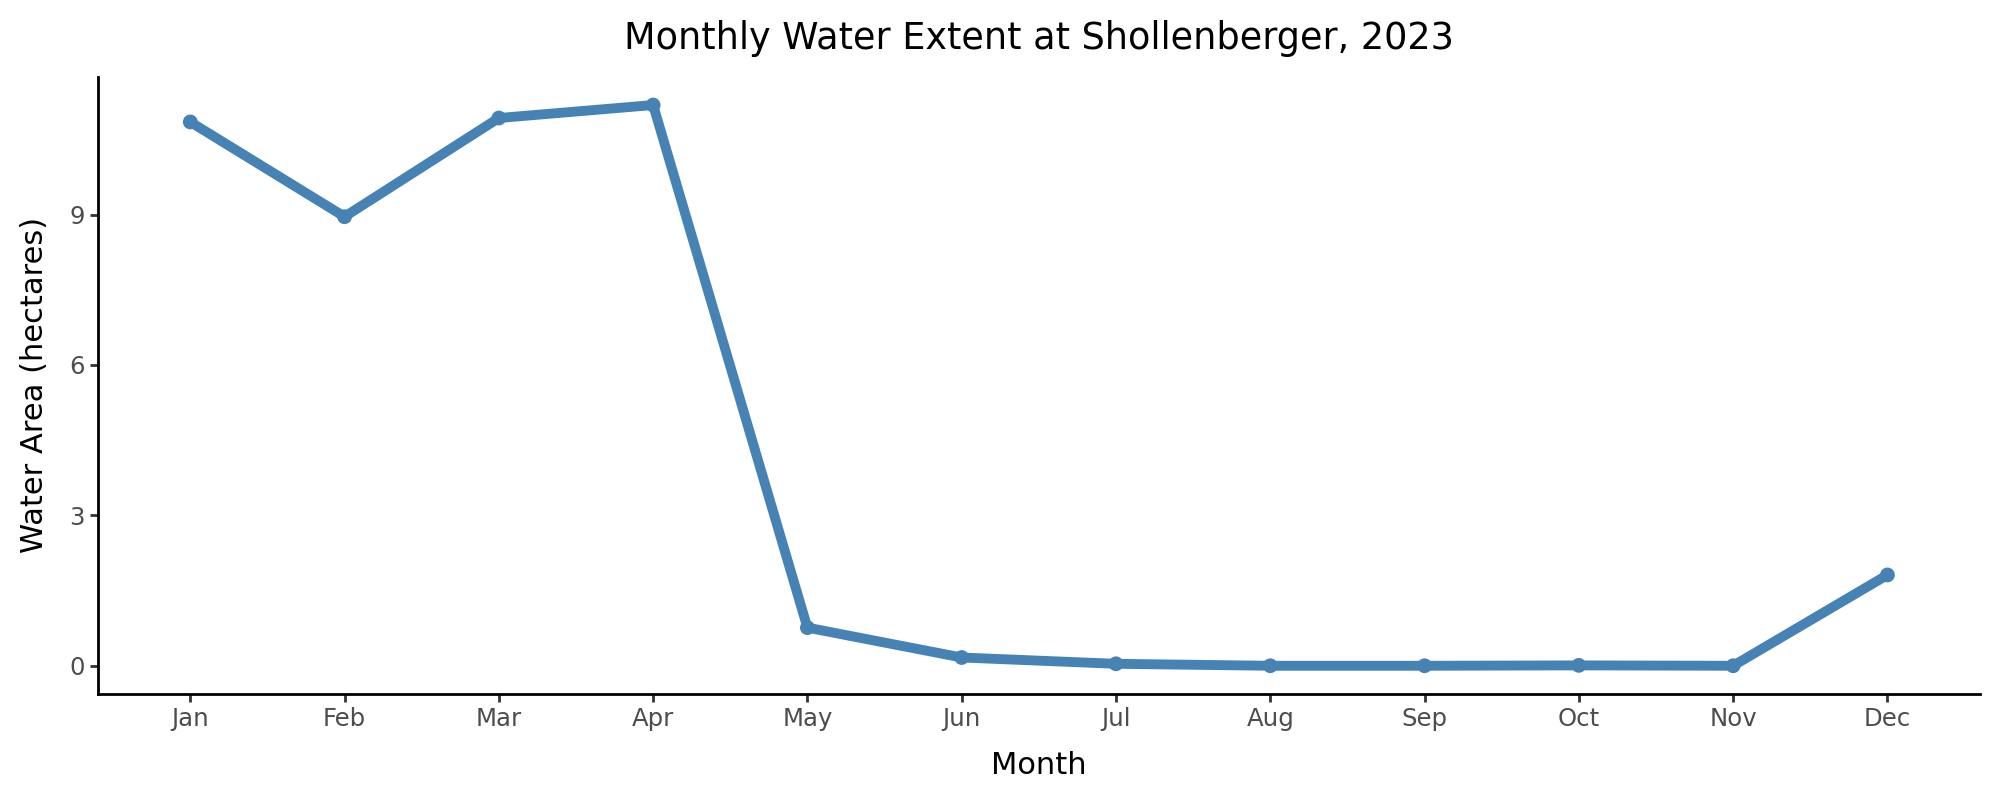

In [ ]:
months = range(1, 13) # create months
water_areas = [] # empty list, filled below

# Loop everything twelve times, for each month
for month in months:
    # Create monthly median composite
    monthly = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(shollenberger_poly)
        .filter(ee.Filter.calendarRange(month, month, 'month'))
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
        .median())

    # Calculate NDWI
    ndwi = monthly.normalizedDifference(['B3', 'B8'])

    # Count water pixels (above 0.2 threshold)
    water_mask = ndwi.gt(0.2)
    water_area = water_mask.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=shollenberger_poly,
        scale=10
    ).get('nd')

    # Use getInfo to pull numbers from Google into Python
    water_areas.append(water_area.getInfo() / 10000)  # convert m2 to hectares
    print(f'Month {month} done')  # progress tracker when running

# Assign month names
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Plot
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(month_names, water_areas, color='steelblue', linewidth=2, marker='o', markersize=5)
ax.fill_between(month_names, water_areas, alpha=0.2, color='steelblue')  # shaded area

ax.set_title('Monthly Water Extent at Shollenberger, 2023', fontsize=13, pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Water Area (hectares)')
ax.spines[['top', 'right']].set_visible(False)  # remove top and right border
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('shollenberger_water_extent.png', dpi=300)
plt.show()